# Stack Overflow Developer Survey Analysis

## Objective
The goal of this project is to analyze developer trends, using real-world survey data.

## Key Focus Areas
- Developer experience
- Remote work trends
- Python popularity
- Salary distribution
- Learning paths

In [1]:
import pandas as pd
# Load datasets
df = pd.read_csv('survey_results_public.csv', low_memory=False)
schema = pd.read_csv('survey_results_schema.csv')

In [2]:
## Initial Data Exploration

df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), object(119)
memory usage: 64.6+ MB


### Insight
The dataset contains a large number of respondents and multiple features, making it suitable for meaningful analysis.

In [3]:
## Task 1: Total Number of Respondents
total_respondents = df.shape[0]
total_respondents

49191

### Insight
The dataset includes a substantial number of respondents, ensuring reliable analysis.

In [4]:
## Task 2: Data Completeness

questions = set(schema['qname'])

cols = set(df.columns)
relevant_cols = list(questions.intersection(cols))

complete_responses = df[relevant_cols].dropna()
complete_count = complete_responses.shape[0]

complete_count

0

### Insight
No respondent completed every single question — this is expected in large surveys. Analysis should be done per-topic, not on fully complete rows.

In [5]:
## Task 3: Work Experience Analysis

workexp = df['WorkExp']

mean_val = workexp.mean()
median_val = workexp.median()
mode_val = workexp.mode()

pd.Series({
    'Mean': mean_val,
    'Median': median_val,
    'Mode': mode_val.iloc[0] if not mode_val.empty else None
})

Mean      13.367403
Median    10.000000
Mode      10.000000
dtype: float64

### Insight
Median experience provides a more reliable measure due to outliers in the data.

In [6]:
## Task 4: Remote Work Analysis 

df['RemoteWork'].value_counts()

RemoteWork
Remote                                                                          10931
Hybrid (some remote, leans heavy to in-person)                                   6732
In-person                                                                        6042
Hybrid (some in-person, leans heavy to flexibility)                              5831
Your choice (very flexible, you can come in when you want or just as needed)     4244
Name: count, dtype: int64

In [7]:
remote_count = df[df['RemoteWork'] == 'Remote'].shape[0]
remote_count

10931

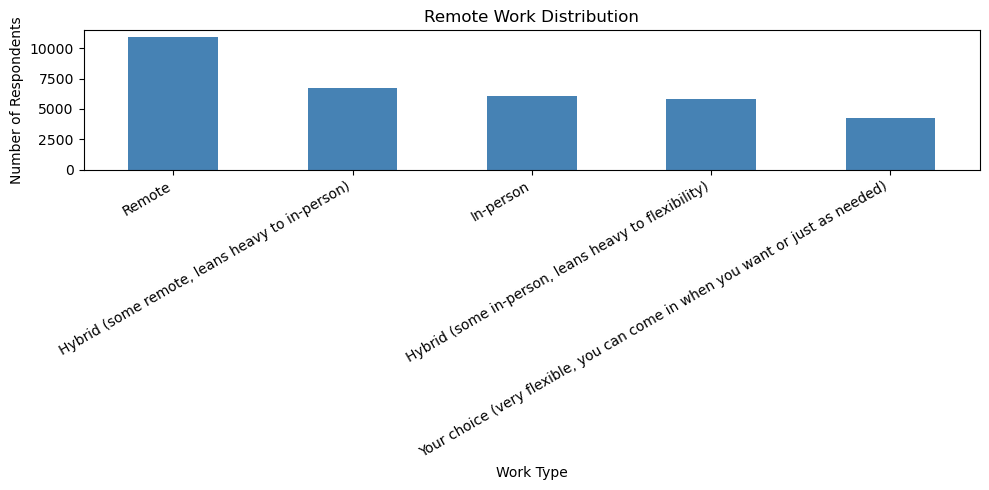

In [8]:
import matplotlib.pyplot as plt

remote_counts = df['RemoteWork'].value_counts()

plt.figure(figsize=(10, 5))
remote_counts.plot(kind='bar', color='steelblue')
plt.title('Remote Work Distribution')
plt.xlabel('Work Type')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Insight
Remote work is widely adopted, reflecting modern work trends in tech.

In [9]:
## Task 5: Python Usage

python_users = df['LanguageHaveWorkedWith'].str.contains('Python', na=False)

percentage = python_users.mean() * 100
round(percentage, 2)

np.float64(37.54)

### Insight
Python is one of the most widely used programming languages among developers.

In [10]:
## Task 6: Online Learning

online_learners = df['LearnCode'].str.contains('Online Courses', na=False)

online_count = online_learners.sum()
online_count

np.int64(10973)

### Insight
Online courses are a major source of learning for developers.

In [11]:
## Task 7: Salary Analysis for Python Developers

python_df = df[df['LanguageHaveWorkedWith'].str.contains('Python', na=False)]

python_df = python_df.dropna(subset=['ConvertedCompYearly'])

salary_stats = python_df.groupby('Country')['ConvertedCompYearly'].agg(['mean', 'median'])

salary_stats.head()



,mean,median
Country,,
Afghanistan,22328.666667,1000.0
Albania,47217.600000,50000.0
Algeria,20187.285714,7088.0
Andorra,226103.500000,226103.5
Antigua and Barbuda,1.000000,1.0


In [12]:
salary_stats = python_df.groupby('Country')['ConvertedCompYearly'].agg(['mean', 'median', 'count'])
salary_stats = salary_stats[salary_stats['count'] >= 30].sort_values('median', ascending=False)

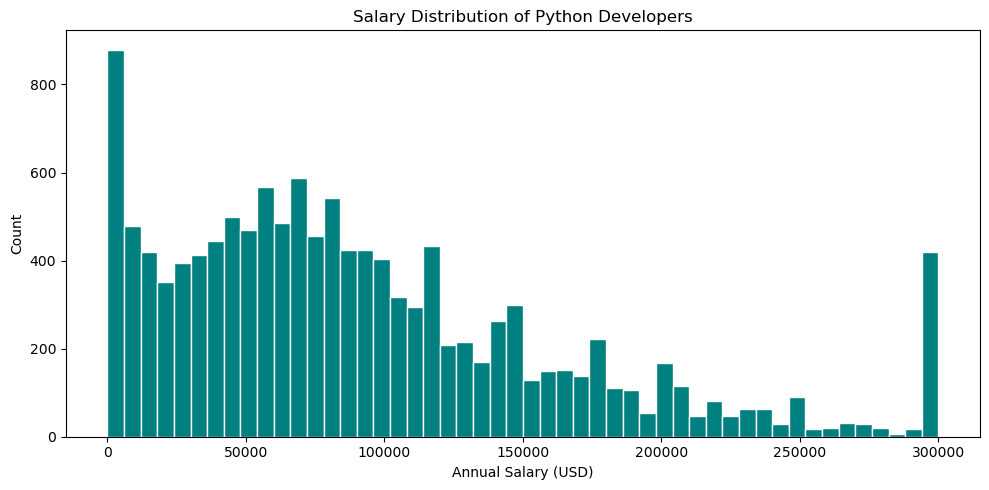

In [13]:
python_df['ConvertedCompYearly'].clip(upper=300000).plot(
    kind='hist', bins=50, figsize=(10, 5), color='teal', edgecolor='white'
)
plt.title('Salary Distribution of Python Developers')
plt.xlabel('Annual Salary (USD)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Insight
Salary varies significantly across countries, and median is more robust than mean.

In [14]:
## Task 8: Top Earners Education

top5 = df.sort_values(by='ConvertedCompYearly', ascending=False).head(5)

top5[['ConvertedCompYearly', 'EdLevel']]

,ConvertedCompYearly,EdLevel
34267,50000000.0,"Associate degree (A.A., A.S., etc.)"
28700,33552715.0,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)"
43143,18387548.0,"Associate degree (A.A., A.S., etc.)"
35353,15430267.0,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)"
45971,13921760.0,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)"


### Insight
Top earners come from diverse educational backgrounds.

In [15]:
## Task 9: Python Usage by Age

df['Python'] = df['LanguageHaveWorkedWith'].str.contains('Python', na=False)

age_python = df.groupby('Age')['Python'].mean() * 100

age_python.reset_index()

,Age,Python
0,18-24 years old,40.000000
1,25-34 years old,36.939282
2,35-44 years old,36.719281
3,45-54 years old,38.629482
4,55-64 years old,37.242955
5,65 years or older,31.634820
6,Prefer not to say,31.216931


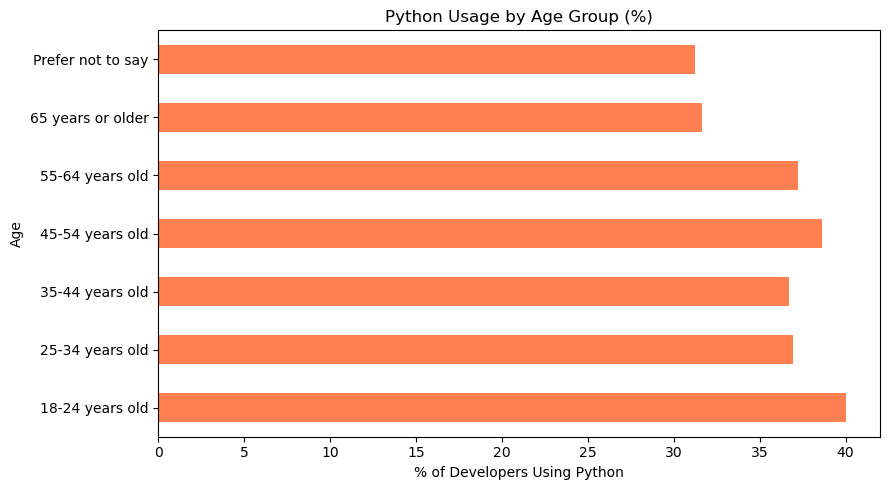

In [16]:
## Task 10: Top Industries for High-earning Remote Workers

age_python.plot(
    x='Age', y='Python',
    kind='barh', figsize=(9, 5), color='coral'
)
plt.title('Python Usage by Age Group (%)')
plt.xlabel('% of Developers Using Python')
plt.tight_layout()
plt.show()

### Insight
Python is most popular among the youngest developers (18–24), with adoption gradually declining with age. This suggests Python is increasingly becoming the entry-level language of choice for new developers.

In [17]:
threshold = df['ConvertedCompYearly'].quantile(0.75)

filtered = df[
    (df['ConvertedCompYearly'] >= threshold) &
    (df['RemoteWork'] == 'Remote')
]

filtered['Industry'].value_counts().head(10)

Industry
Software Development                          1186
Fintech                                        190
Healthcare                                     188
Other:                                         176
Internet, Telecomm or Information Services     138
Banking/Financial Services                      88
Government                                      78
Media & Advertising Services                    75
Retail and Consumer Services                    65
Transportation, or Supply Chain                 63
Name: count, dtype: int64

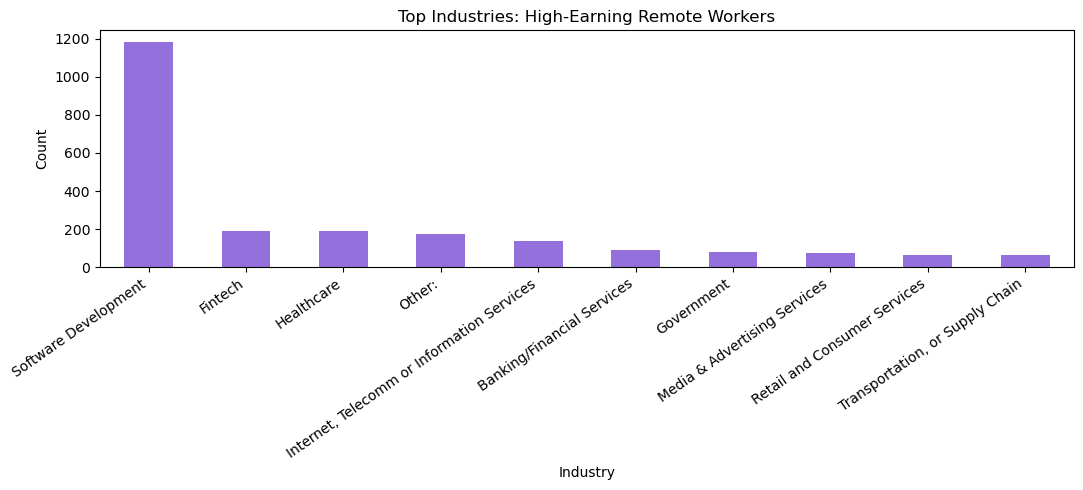

In [18]:
filtered['Industry'].value_counts().head(10).plot(
    kind='bar', figsize=(11, 5), color='mediumpurple'
)
plt.title('Top Industries: High-Earning Remote Workers')
plt.xlabel('Industry')
plt.ylabel('Count')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

### Insight
Software Development dominates among high-earning remote workers by a large margin, followed by Fintech and Healthcare. This indicates that remote high-paying opportunities are heavily concentrated in tech-adjacent industries.